In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src import (
    QlearningGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
gamma_grid = pd.read_csv("Results_FPA/Parameter asymmetry/parameter_grid_results_FPA_gamma.csv")
gamma_09 = pd.read_csv("Results_FPA/Parameter asymmetry/parameter_grid_results_FPA_gamma09.csv")

In [8]:
gamma_grid.head()

,grid_id,trial,gamma_agent1,gamma_agent2,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,11,0,0.25,0.25,3848.0,0.65,0.210041,0.65,0.258039
1,11,1,0.25,0.25,2593.0,0.15,0.584562,0.15,0.546180
2,11,2,0.25,0.25,4754.0,0.50,0.252978,0.50,0.401912
3,11,3,0.25,0.25,4929.0,0.80,0.114466,0.80,0.152483
4,11,4,0.25,0.25,3141.0,0.45,0.369269,0.45,0.367119


In [9]:
gamma_09.head()

,grid_id,trial,gamma_agent1,gamma_agent2,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,1,0,0.9,0.9,11169,0.45,2.721185,0.45,2.776756
1,1,1,0.9,0.9,10589,0.35,3.094819,0.35,3.357366
2,1,2,0.9,0.9,10018,0.35,3.499380,0.35,3.000484
3,1,3,0.9,0.9,8439,0.30,3.508736,0.30,3.455108
4,1,4,0.9,0.9,7671,0.10,4.455515,0.10,4.512234


In [10]:
# 1) Merge
merged_gamma = pd.concat([gamma_grid, gamma_09], ignore_index=True)

# 2) New ordered gamma grid and index map
gammas = [0.25, 0.5, 0.75, 0.9, 0.99, 0.999]
gamma_to_idx = {g: i+1 for i, g in enumerate(gammas)}

# helper to be robust to float representations
def to_idx(x):
    for g in gammas:
        if np.isclose(x, g, atol=1e-12):
            return gamma_to_idx[g]
    raise ValueError(f"gamma {x} not in allowed set {gammas}")

# recompute grid_id from (gamma_agent1, gamma_agent2)
merged_gamma["grid_id"] = (
    merged_gamma["gamma_agent1"].apply(to_idx) * 10
    + merged_gamma["gamma_agent2"].apply(to_idx)
)

# 3) Optional: sort nicely
merged_gamma = merged_gamma.sort_values(["grid_id", "trial"], ignore_index=True)

# 4) (Optional) quick sanity checks
expected_ids = {10*i + j for i in range(1, 7) for j in range(1, 7)}
present_ids  = set(merged_gamma["grid_id"].unique())

print("Unique grid_ids present:", sorted(present_ids)[:10], "...")
missing = sorted(expected_ids - present_ids)
if missing:
    print("WARNING: missing combinations (grid_ids):", missing)
else:
    print("All 36 combinations present.")

# merged now has your unified dataset with the new grid_id scheme
# Save if you like:
# merged.to_csv("gamma_merged_new_grid.csv", index=False)


Unique grid_ids present: [np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26)] ...


In [27]:
def plot_convergence_grid(df, save=False, title=None):
    # 1) Filter out NA convergence
    df = df.dropna(subset=["rounds_to_convergence"]).copy()

    # 1.1) Filter out instances where algorithms converge to different results
    df = df.dropna(subset=["converged_bid_Agent1", "converged_bid_Agent2"]).copy()
    mask = np.isclose(df["converged_bid_Agent1"], df["converged_bid_Agent2"], rtol=0.0, atol=1e-9)
    df = df.loc[mask]

    # 2) Boolean flag: did both converge to 0.95?
    df["converged_to_095"] = (
        np.isclose(df["converged_bid_Agent1"], 0.95, atol=1e-12)
        & np.isclose(df["converged_bid_Agent2"], 0.95, atol=1e-12)
    )

    # 3) Aggregate: percentage per (gamma1, gamma2)
    agg = (
        df.groupby(["gamma_agent1", "gamma_agent2"])["converged_to_095"]
        .mean()
        .reset_index()
    )
    agg["percent"] = 100 * agg["converged_to_095"]

    # 4) Pivot to 2D grid
    pivot = agg.pivot(index="gamma_agent2", columns="gamma_agent1", values="percent")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 5) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% converged to 0.95"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title("Convergence to bid=0.95 across γ-grid")
    plt.xlabel("γ Agent 1")
    plt.ylabel("γ Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()


In [12]:
def upper_left_only(df, tol=1e-12):
    g1 = df["gamma_agent1"].to_numpy()
    g2 = df["gamma_agent2"].to_numpy()
    mask = (g1 < g2) | np.isclose(g1, g2, atol=tol)   # keep gamma1 <= gamma2
    df_ul = df.loc[mask].copy()
    return df_ul


In [13]:
# Make a copy to be safe
df_swapped = merged_gamma.copy()

# Define the pairs you want to swap
to_swap = {(0.9, 0.25), (0.9, 0.5), (0.9, 0.75)}

# Iterate through each pair and swap gamma_agent1 <-> gamma_agent2
for g1, g2 in to_swap:
    mask = np.isclose(df_swapped["gamma_agent1"], g1) & np.isclose(df_swapped["gamma_agent2"], g2)
    df_swapped.loc[mask, ["gamma_agent1", "gamma_agent2"]] = df_swapped.loc[mask, ["gamma_agent2", "gamma_agent1"]].values

In [14]:
gamma_grid_final = upper_left_only(df_swapped)

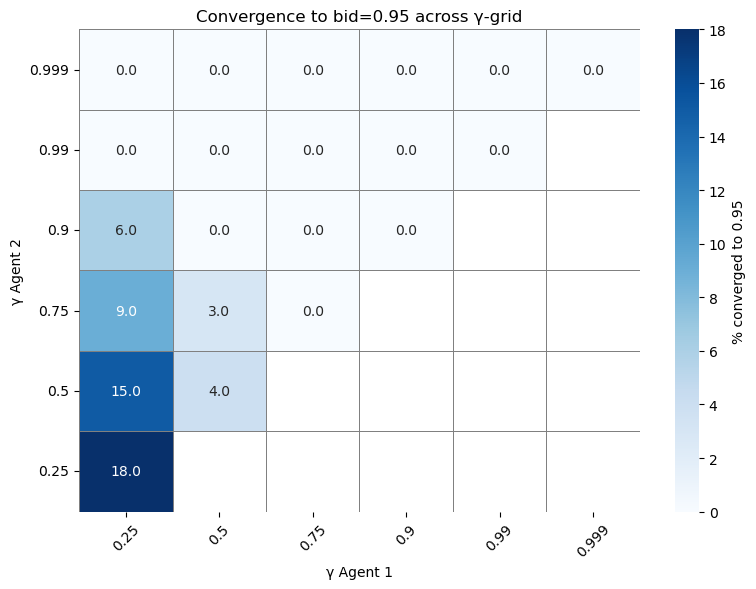

In [15]:
plot_convergence_grid(gamma_grid_final)

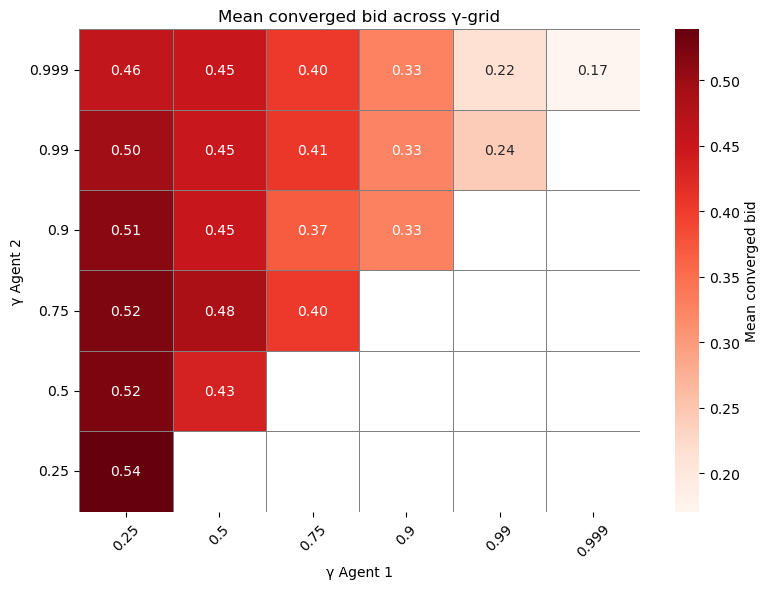

In [16]:
def plot_mean_bid_grid(df, agent="Agent1", save=False, title=None):
    # 1) Filter out NA convergence values
    df = df.dropna(subset=[f"converged_bid_{agent}"]).copy()

    # 2) Aggregate: mean bid per (gamma1, gamma2)
    agg = (
        df.groupby(["gamma_agent1", "gamma_agent2"])[f"converged_bid_{agent}"]
        .mean()
        .reset_index()
    )

    # 3) Pivot to 2D grid
    pivot = agg.pivot(index="gamma_agent2", columns="gamma_agent1", values=f"converged_bid_{agent}")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 4) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": f"Mean converged bid"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title(f"Mean converged bid across γ-grid")
    plt.xlabel("γ Agent 1")
    plt.ylabel("γ Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True and title is not None:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

plot_mean_bid_grid(gamma_grid_final)

### Alpha parameter grid:

In [17]:
alpha_grid = pd.read_csv("Results_FPA/Parameter asymmetry/parameter_grid_results_FPA_alpha.csv")

In [18]:
alpha_grid.head()

,grid_id,trial,alpha_agent1,alpha_agent2,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,11,0,0.01,0.01,399146,0.20,27.929947,0.20,28.104592
1,11,1,0.01,0.01,390115,0.35,27.875158,0.35,27.717652
2,11,2,0.01,0.01,316415,0.15,33.595346,0.15,33.415220
3,11,3,0.01,0.01,295126,0.10,35.557041,0.10,35.383806
4,11,4,0.01,0.01,348128,0.20,31.367308,0.20,30.697965


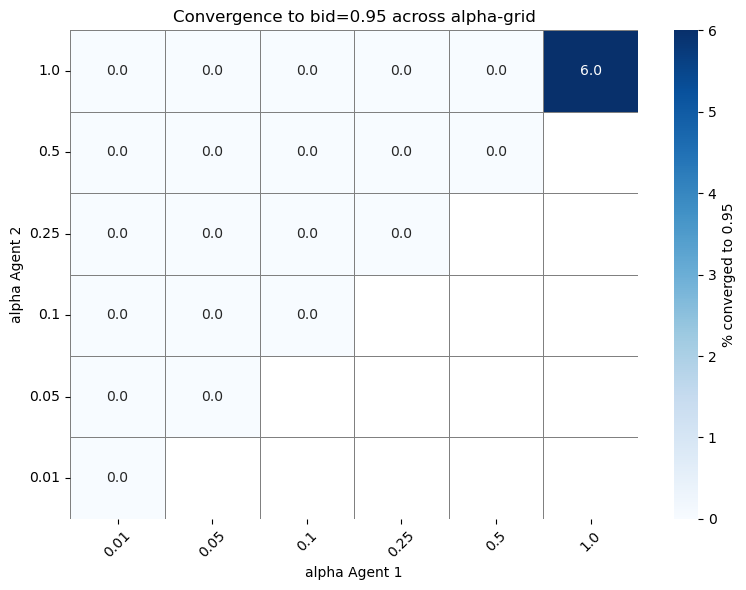

In [29]:
def alpha_plot_convergence_grid(df, save=False, title=None):
    # 1) Filter out NA convergence
    df = df.dropna(subset=["rounds_to_convergence"]).copy()

    # 1.1) Filter out instances where algorithms converge to different results
    df = df.dropna(subset=["converged_bid_Agent1", "converged_bid_Agent2"]).copy()
    mask = np.isclose(df["converged_bid_Agent1"], df["converged_bid_Agent2"], rtol=0.0, atol=1e-9)
    df = df.loc[mask]
    
    # 2) Boolean flag: did both converge to 0.95?
    df["converged_to_095"] = (
        np.isclose(df["converged_bid_Agent1"], 0.95, atol=1e-12)
        & np.isclose(df["converged_bid_Agent2"], 0.95, atol=1e-12)
    )

    # 3) Aggregate: percentage per (gamma1, gamma2)
    agg = (
        df.groupby(["alpha_agent1", "alpha_agent2"])["converged_to_095"]
        .mean()
        .reset_index()
    )
    agg["percent"] = 100 * agg["converged_to_095"]

    # 4) Pivot to 2D grid
    pivot = agg.pivot(index="alpha_agent2", columns="alpha_agent1", values="percent")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 5) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% converged to 0.95"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title("Convergence to bid=0.95 across alpha-grid")
    plt.xlabel("alpha Agent 1")
    plt.ylabel("alpha Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()
    
alpha_plot_convergence_grid(alpha_grid)

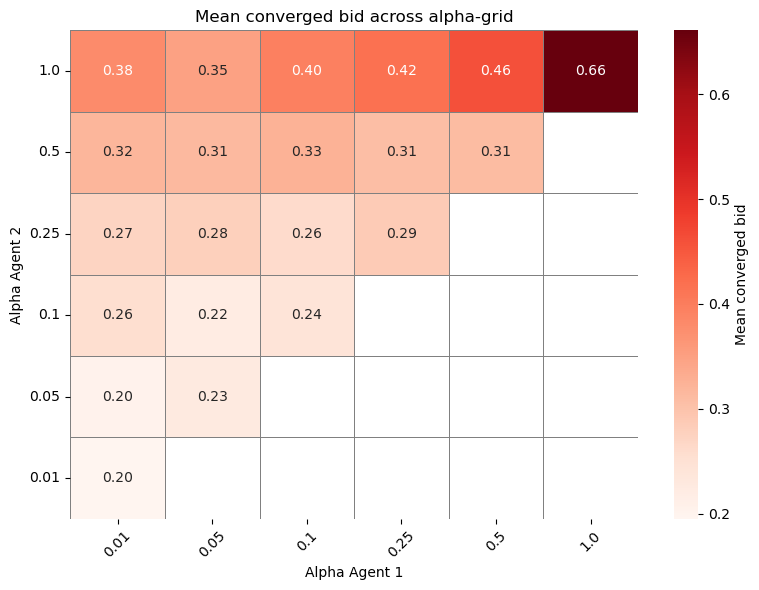

In [33]:
def alpha_mean_bid_grid(df, save=False, title=None):
    # 1) Filter out NA convergence values
    df = df.dropna(subset=["converged_bid_Agent1"]).copy()

    # 2) Aggregate: mean bid per (gamma1, gamma2)
    agg = (
        df.groupby(["alpha_agent1", "alpha_agent2"])["converged_bid_Agent1"]
        .mean()
        .reset_index()
    )

    # 3) Pivot to 2D grid
    pivot = agg.pivot(index="alpha_agent2", columns="alpha_agent1", values=f"converged_bid_Agent1")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 4) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": f"Mean converged bid"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title(f"Mean converged bid across alpha-grid")
    plt.xlabel("Alpha Agent 1")
    plt.ylabel("Alpha Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True and title is not None:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

alpha_mean_bid_grid(alpha_grid)

### Beta (exploration decay rate) analysis

In [21]:
beta_grid = pd.read_csv("Results_FPA/Parameter asymmetry/parameter_grid_results_FPA_beta.csv")

In [22]:
beta_grid.head()

,grid_id,trial,beta_agent1,beta_agent2,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,11,0,0.0,0.0,80112,0.20,31.970119,0.20,31.652680
1,11,1,0.0,0.0,69827,0.25,32.753630,0.25,33.151439
2,11,2,0.0,0.0,76198,0.35,29.748203,0.35,29.807274
3,11,3,0.0,0.0,65886,0.25,34.014479,0.25,33.664886
4,11,4,0.0,0.0,72049,0.25,31.895857,0.25,32.764493


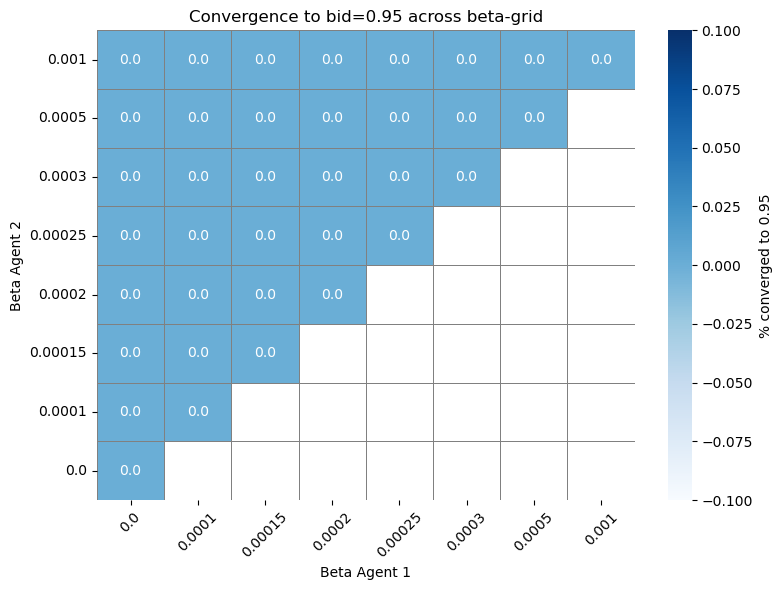

In [ ]:
def beta_convergence_grid(df, save=False, title=None):
    # 1) Filter out NA convergence
    df = df.dropna(subset=["rounds_to_convergence"]).copy()

    # 1.1) Filter out instances where algorithms converge to different results
    df = df.dropna(subset=["converged_bid_Agent1", "converged_bid_Agent2"]).copy()
    mask = np.isclose(df["converged_bid_Agent1"], df["converged_bid_Agent2"], rtol=0.0, atol=1e-9)
    df = df.loc[mask]

    # 2) Boolean flag: did both converge to 0.95?
    df["converged_to_095"] = (
        np.isclose(df["converged_bid_Agent1"], 0.95, atol=1e-12)
        & np.isclose(df["converged_bid_Agent2"], 0.95, atol=1e-12)
    )

    # 3) Aggregate: percentage per (gamma1, gamma2)
    agg = (
        df.groupby(["beta_agent1", "beta_agent2"])["converged_to_095"]
        .mean()
        .reset_index()
    )
    agg["percent"] = 100 * agg["converged_to_095"]

    # 4) Pivot to 2D grid
    pivot = agg.pivot(index="beta_agent2", columns="beta_agent1", values="percent")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 5) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% converged to 0.95"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title("Convergence to bid=0.95 across beta-grid")
    plt.xlabel("Beta Agent 1")
    plt.ylabel("Beta Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

beta_convergence_grid(beta_grid)   

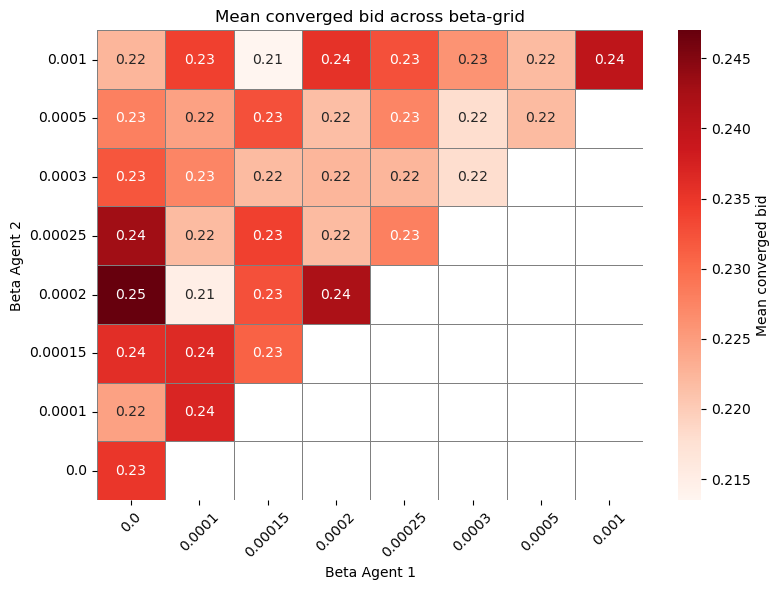

In [24]:
def beta_mean_convergence_grid(df, save=False, title=None):
    # 1) Filter out NA convergence values
    df = df.dropna(subset=["converged_bid_Agent1"]).copy()

    # 2) Aggregate: mean bid per (gamma1, gamma2)
    agg = (
        df.groupby(["beta_agent1", "beta_agent2"])["converged_bid_Agent1"]
        .mean()
        .reset_index()
    )

    # 3) Pivot to 2D grid
    pivot = agg.pivot(index="beta_agent2", columns="beta_agent1", values="converged_bid_Agent1")

    # --- reverse y-axis order ---
    pivot = pivot.reindex(index=sorted(pivot.index, reverse=True))

    # 4) Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": f"Mean converged bid"},
        linewidths=0.5, linecolor="gray"
    )
    plt.title(f"Mean converged bid across beta-grid")
    plt.xlabel("Beta Agent 1")
    plt.ylabel("Beta Agent 2")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save == True and title is not None:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

beta_mean_convergence_grid(beta_grid)

### Second-Price Auction

In [25]:
SPA_gamma_grid = pd.read_csv("Results_SPA/Parameter/parameter_grid_results_SPA_gamma.csv")
SPA_alpha_grid = pd.read_csv("Results_SPA/Parameter/parameter_grid_results_SPA_alpha.csv")
SPA_beta_grid = pd.read_csv("Results_SPA/Parameter/parameter_grid_results_SPA_beta.csv")

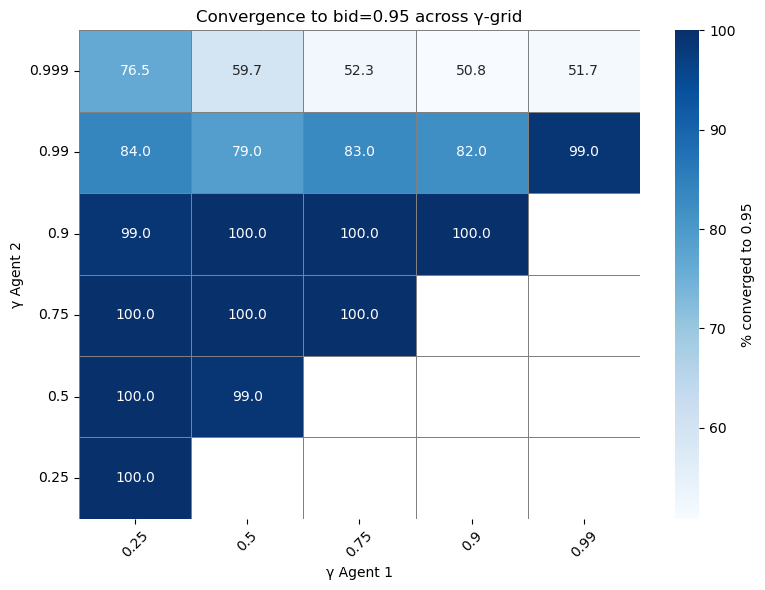

In [26]:
plot_convergence_grid(SPA_gamma_grid)

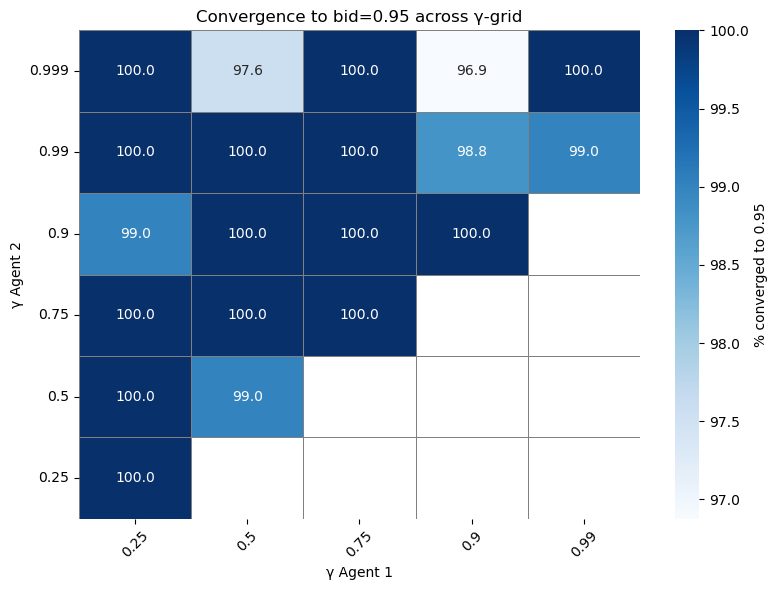

In [28]:
plot_convergence_grid(SPA_gamma_grid)

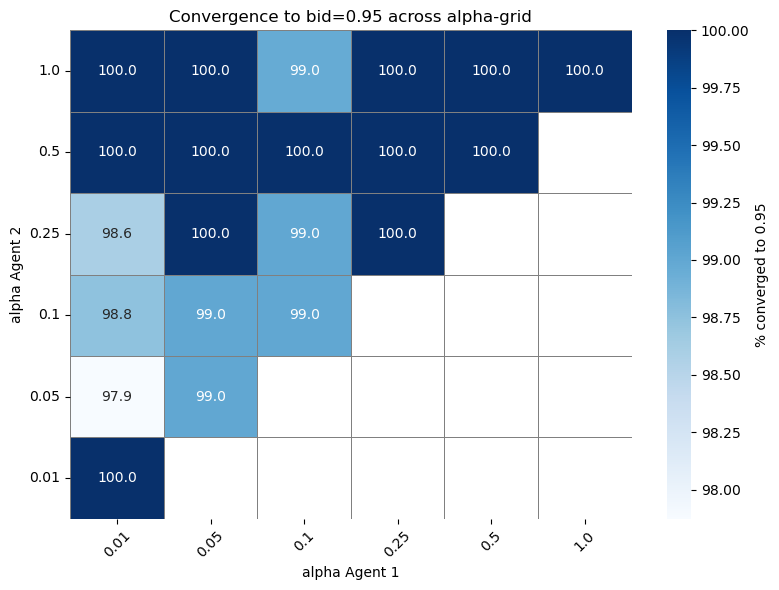

In [34]:
alpha_plot_convergence_grid(SPA_alpha_grid)

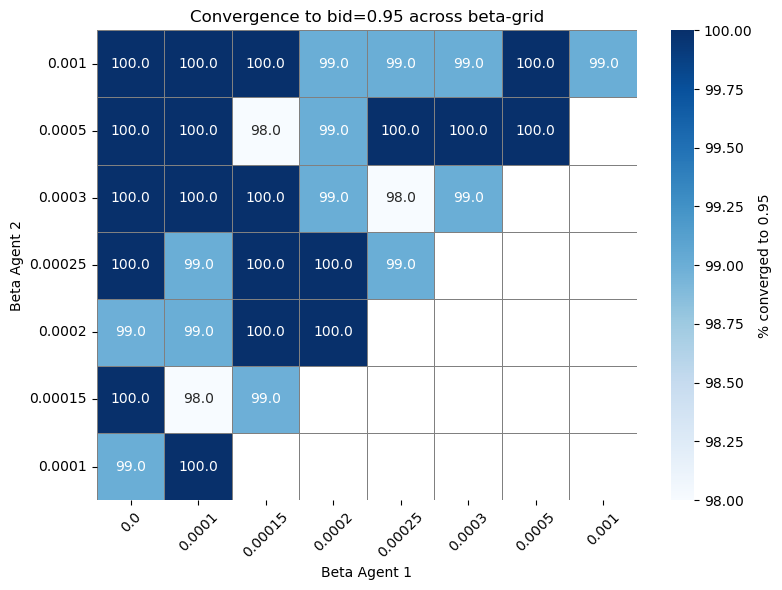

In [32]:
beta_convergence_grid(SPA_beta_grid)